In [1]:
import numpy as np
import finufft
import matplotlib.pyplot as pl
from scipy.interpolate import CubicSpline

pi = np.pi

In [2]:
def strobo(new_t, data, f_ratio):
    f_new = f_signal/f_ratio
    
    new_t *= f_new #changes the frequency to the new downsampled frequency (approximately, not exactly)
    floor_t = np.floor(new_t) #For some reason floor works better than round. Take it to the nearest time index which are integers
    idx = np.nonzero(np.diff(floor_t)) #The step that downsamples
    resampled = data[idx]
    t_out = (new_t[idx]-new_t[0])/f_new
    return (resampled, t_out)

## Spindown

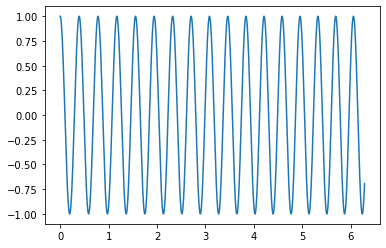

In [7]:
points = 2**16
t = np.linspace(0, 2*pi, points, endpoint=False)
f_signal = points/(2*pi)
f0 = 16 # rad/s
fdot = 0.1 # rad/s^2 

signal = np.real(1*np.exp(1j*(f0+fdot*t)*t))
pl.plot(t, signal)

# tau = t*(1+fdot/f0*t)
# phi = np.mod(phi, 2*pi)

In [8]:
f_ratio = 32
new_t = t*(1+fdot/f0*t)
out, t_out = strobo(new_t, signal, f_ratio)
corrected = np.fft.fftshift(np.fft.fft(out))
freq_corrected = np.fft.fftshift(np.fft.fftfreq(len(t_out), d=t_out[1]-t_out[0]))
resampled_power = np.abs(corrected)**2
freq_corrected = freq_corrected

In [9]:
signal = signal[::f_ratio]
t = t[::f_ratio]

In [10]:
tau = t*(1+fdot/f0*t)
scale = (2*pi)/(tau[-1]-tau[0])
tau *= scale
start_diff = -tau[0]
tau += start_diff

bin_no = points//f_ratio
nufft_freqs = (np.arange(bin_no) - bin_no//2)/(2*pi)
nufft_amps = finufft.nufft1d1(tau, signal.astype(complex), bin_no)
nufft_power = abs(nufft_amps**2)

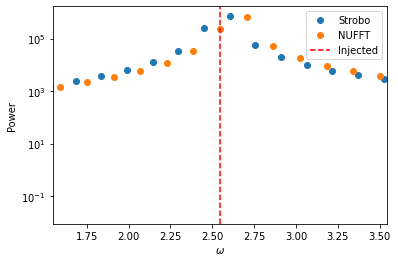

In [11]:
pl.semilogy(freq_corrected, resampled_power, 'o', label = 'Strobo')
pl.semilogy(nufft_freqs, nufft_power, 'o', label = 'NUFFT')

pl.axvline(f0/(2*pi), c='r', ls = '--', label = 'Injected')
pl.xlim(f0/(2*pi)-1, f0/(2*pi)+1)
pl.xlabel(r'$\omega$')
pl.ylabel('Power')
pl.legend()

## Inspiral signal

In [12]:
c = 3e8
G = 6.67e-11
pi = np.pi
const = 96/5*pi**(8/3)*(G/c**3)**(5/3)

f0 = 20
Mc = 3e-2* 2e30
f_max = 200
T_obs = 1e4
# pad_len = int(340*T_obs) #~0.01 added length to resampled data
beta = const*f0**(8/3)*Mc**(5/3)
f_signal = 40*f_max
nt = round(f_signal*T_obs)
t = (np.arange(nt)/f_signal)#.astype(np.longdouble)
f_ratio = 25

phi = -6*pi/5*f0*(1-8./3.*(beta)*t)**(5/8)/beta
# phi = np.mod(phi,2*pi)
signal = 1*np.exp(1j*phi)

In [13]:
f_ratio = 25
new_t = -3/5*(1-8/3*beta*t)**(5/8)/beta
out, t_out = strobo(new_t, signal, f_ratio)
corrected = np.fft.fftshift(np.fft.fft(out))
freq_corrected = np.fft.fftshift(np.fft.fftfreq(len(t_out), d=t_out[1]-t_out[0]))
corrected = corrected/len(out)
resampled_power = np.abs(corrected)**2

freq_corrected = freq_corrected
nt_new = len(out)

In [14]:
tau = -3/5*(1-8/3*beta*t)**(5/8)/beta
scale = (2*pi)/(tau[-1]-tau[0])
tau *= scale
start_diff = -pi-tau[0]
tau += start_diff

In [15]:
bin_no = int(len(resampled_power))
bins = np.arange(bin_no) - bin_no//2

f = finufft.nufft1d1(tau.astype(np.float64), signal.astype(complex), bin_no)
nufft_power = abs(f/len(signal))**2
nufft_freq = -bins*scale/(2*pi)
# pl.plot(bins, abs(f)**2, 'o')
# pl.xlim(-20050 - 200, -20050 +200)
found = nufft_freq[np.argmax(nufft_power)]
print('Maximum power at f = %.2f' % (found))

Maximum power at f = 20.00


Text(0.5, 0.98, 'NUFFT kernel function has an effect on the Fourier spectrum')

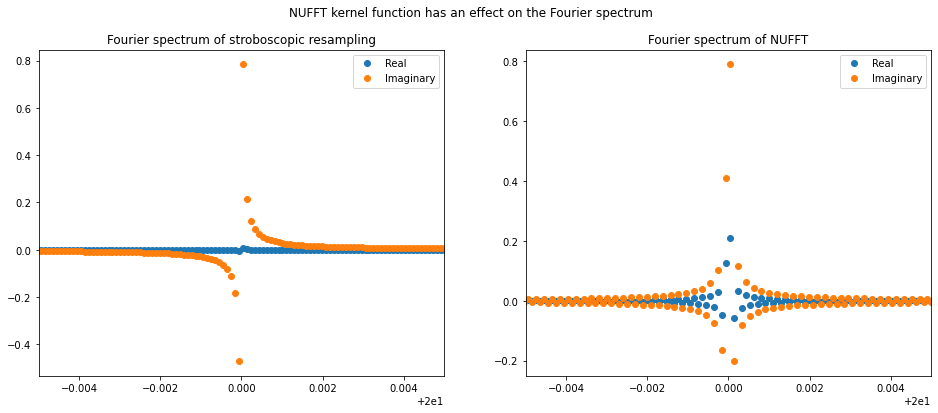

In [16]:
fig, axs = pl.subplots(ncols = (2), figsize=(16, 6))

axs[0].plot(freq_corrected, np.real(corrected), 'o', label='Real')
axs[0].plot(freq_corrected, np.imag(corrected), 'o', label="Imaginary")
axs[0].set_xlim(19.995, 20.005)
axs[0].set_title('Fourier spectrum of stroboscopic resampling')
axs[0].legend()

axs[1].plot(nufft_freq, np.real(f/len(signal)), 'o', label='Real')
axs[1].plot(nufft_freq, np.imag(f/len(signal)), 'o', label='Imaginary')
axs[1].set_xlim(19.995, 20.005)
axs[1].set_title('Fourier spectrum of NUFFT')
axs[1].legend()

fig.suptitle("NUFFT kernel function has an effect on the Fourier spectrum")

Text(0.5, 1.0, 'Power spectrum for strobo vs NUFFT')

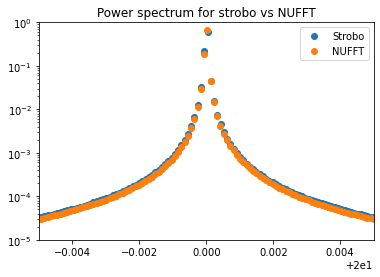

In [19]:
pl.semilogy(freq_corrected, resampled_power,'o', label='Strobo')
pl.semilogy(nufft_freq, nufft_power, 'o', label='NUFFT')
pl.xlim(19.995, 20.005)
pl.ylim(1e-5, 1e0)
pl.legend()
pl.title("Power spectrum for strobo vs NUFFT")

<>:8: DeprecationWarning: invalid escape sequence \s
<>:8: DeprecationWarning: invalid escape sequence \s
<>:8: DeprecationWarning: invalid escape sequence \s
/tmp/ipykernel_7120/1433258449.py:8: DeprecationWarning: invalid escape sequence \s
  pl.title("Points more than 6$\sigma$ above the noise level")


Text(20.0015, 0.45, 'Strobo power = 0.971 \nNUFFT power = 0.974')

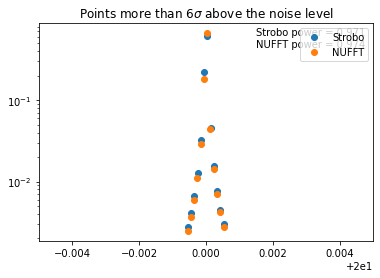

In [18]:
strobo_peak = resampled_power>np.median(resampled_power)+6*np.std(resampled_power)
pl.plot(freq_corrected[strobo_peak], resampled_power[strobo_peak], 'o', label='Strobo')

nufft_peak = nufft_power>np.median(nufft_power)+6*np.std(nufft_power)
pl.semilogy(nufft_freq[nufft_peak], nufft_power[nufft_peak], 'o', label="NUFFT")
pl.xlim(19.995, 20.005)
pl.legend()
pl.title("Points more than 6$\sigma$ above the noise level")
pl.text(20+0.0015, 0.45, 'Strobo power = %.3f \nNUFFT power = %.3f' 
        % (np.sum(resampled_power[strobo_peak]), np.sum(nufft_power[nufft_peak])))